# 🛍️ AI Product Intelligence System — Day 2 Homework

**Name:** Venkat Gopi Juturi  
**Batch:** 2027 | AI & ML  
**Institution:** AVN Institute of Engineering and Technology

---

## Overview

This notebook implements an **AI-powered Product Intelligence System** using state-of-the-art vision-language models:

| Task | Description | Model Used |
|------|-------------|------------|
| **Setup** | Load dataset + models (BLIP, CLIP, FAISS) | BLIP + CLIP |
| **Task 1** | Smart Product Recommendation Engine | CLIP + Category Logic |
| **Task 2** | Unique Product Catalog (Deduplication) | CLIP + Cosine Similarity |
| **Task 3** | Reverse Product Search (Text → Products) | CLIP Text Embeddings + FAISS |

---

## 📦 Step 1: Install & Import Libraries

In [94]:
!pip install -q faiss-cpu
!pip install -q transformers accelerate sentencepiece

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    CLIPProcessor,
    CLIPModel
)
import faiss

print(f"✅ All libraries imported successfully!")
print(f"📦 FAISS version: {faiss.__version__}")
print(f"🔥 PyTorch version: {torch.__version__}")

✅ All libraries imported successfully!
📦 FAISS version: 1.14.3
🔥 PyTorch version: 2.10.0+cu128


## 🖥️ Step 2: Device Setup

In [95]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {device.upper()}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Device: CUDA
   GPU: Tesla T4
   VRAM: 15.6 GB


## 📊 Step 3: Load Dataset

> **Dataset:** Fashion Product Images (Small) by paramaggarwal
> 
> Add it via: `+ Add Data` → search `fashion-product-images-small`

In [5]:
import os
import pandas as pd
DATA_DIR  = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"
IMG_DIR   = os.path.join(DATA_DIR, "myntradataset/images")
CSV_PATH  = os.path.join(DATA_DIR, "myntradataset/styles.csv")
df = pd.read_csv(CSV_PATH, on_bad_lines='skip')
# Fast: get existing image ids directly from folder
existing_ids = set(int(f.replace('.jpg','')) for f in os.listdir(IMG_DIR) if f.endswith('.jpg'))
df['image_path'] = df['id'].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpg"))
df = df[df['id'].isin(existing_ids)].reset_index(drop=True)
print(f"✅ Dataset loaded!")
print(f"   Total valid products: {len(df):,}")
print(df.columns.tolist())
df[['id','gender','masterCategory','subCategory','articleType','baseColour','productDisplayName']].head()

✅ Dataset loaded!
   Total valid products: 44,419
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']


,id,gender,masterCategory,subCategory,articleType,baseColour,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Puma Men Grey T-shirt


In [ ]:
print("📊 Dataset Statistics")
print("=" * 40)
print(f"  Categories  : {df['masterCategory'].nunique()}")
print(f"  Sub-types   : {df['articleType'].nunique()}")
print(f"  Colours     : {df['baseColour'].nunique()}")
print(f"  Genders     : {df['gender'].unique().tolist()}")
print()
print("Top 10 Article Types:")
print(df['articleType'].value_counts().head(10).to_string())

## 🤖 Step 4: Load AI Models (BLIP + CLIP)

In [99]:
print("⏳ Loading BLIP model (image captioning)...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)
print("✅ BLIP loaded!")

print("⏳ Loading CLIP model (vision-language embeddings)...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("✅ CLIP loaded!")
print("\n🎉 All models ready!")

⏳ Loading BLIP model (image captioning)...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP loaded!
⏳ Loading CLIP model (vision-language embeddings)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP loaded!

🎉 All models ready!


## 🔢 Step 5: Build CLIP Embedding Index (FAISS)

We generate CLIP image embeddings for a sample of products and store them in a FAISS index for fast nearest-neighbour search.

In [100]:
DATA_DIR  = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"
IMG_DIR   = os.path.join(DATA_DIR, "myntradataset/images")
CSV_PATH  = os.path.join(DATA_DIR, "myntradataset/styles.csv")

df = pd.read_csv(CSV_PATH, on_bad_lines='skip')

df['image_path'] = df['id'].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpg"))

df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"✅ Dataset loaded!")
print(f"   Total valid products: {len(df):,}")
print(df.columns.tolist())
df[['id','gender','masterCategory','subCategory','articleType','baseColour','productDisplayName']].head()

✅ Dataset loaded!
   Total valid products: 44,419
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']


,id,gender,masterCategory,subCategory,articleType,baseColour,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Puma Men Grey T-shirt


In [101]:
SAMPLE_SIZE = 500
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

def get_clip_image_embedding(image_path: str):
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = clip_model.vision_model(**inputs)
        features = outputs.pooler_output  # get the tensor directly
        features = clip_model.visual_projection(features)  # project to 512-D
    features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy().astype(np.float32).squeeze()

test_emb = get_clip_image_embedding(df_sample.iloc[0]['image_path'])
print(f"✅ Single test passed! Shape: {test_emb.shape}")

embeddings = []
valid_indices = []

for i, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="🔢 Embedding products"):
    try:
        emb = get_clip_image_embedding(row['image_path'])
        embeddings.append(emb)
        valid_indices.append(i)
    except Exception as e:
        continue

embeddings = np.vstack(embeddings)
df_indexed = df_sample.iloc[valid_indices].reset_index(drop=True)

print(f"✅ Embedded {len(embeddings)} products")
print(f"   Embedding shape: {embeddings.shape}")

✅ Single test passed! Shape: (512,)


🔢 Embedding products: 100%|██████████| 500/500 [00:06<00:00, 74.27it/s]

✅ Embedded 500 products
   Embedding shape: (500, 512)


In [102]:
dim = embeddings.shape[1]          # 512
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(embeddings)

print(f"✅ FAISS index built!")
print(f"   Indexed vectors : {faiss_index.ntotal}")
print(f"   Dimension       : {dim}")

✅ FAISS index built!
   Indexed vectors : 500
   Dimension       : 512


---

# 🎯 Task 1 — Smart Product Recommendation Engine

**Problem:** Suggest complementary products that are commonly bought together.  
**Approach:** Category-based complementary mapping + CLIP similarity re-ranking.

In [103]:
COMPLEMENT_MAP = {
    "Shoes"       : ["Socks", "Casual Shoes", "Sports Sandals"],
    "Tshirts"     : ["Jeans", "Track Pants", "Shorts"],
    "Shirts"      : ["Trousers", "Formal Shoes", "Belts"],
    "Jeans"       : ["Shirts", "Tshirts", "Casual Shoes"],
    "Tops"        : ["Jeans", "Skirts", "Flats"],
    "Watches"     : ["Wallets", "Belts", "Shirts"],
    "Handbags"    : ["Tops", "Flats", "Earrings"],
    "Kurtas"      : ["Churidar", "Dupatta", "Flats"],
    "Dresses"     : ["Heels", "Earrings", "Handbags"],
    "Sports Shoes": ["Track Pants", "Tshirts", "Sports Sandals"],
    "Sweatshirts" : ["Track Pants", "Sports Shoes", "Caps"],
    "Jackets"     : ["Jeans", "Sweatshirts", "Casual Shoes"],
    "Belts"       : ["Trousers", "Formal Shoes", "Shirts"],
    "Sunglasses"  : ["Shirts", "Casual Shoes", "Watches"],
    "Bags"        : ["Shirts", "Tshirts", "Sports Shoes"],
    "Caps"        : ["Tshirts", "Track Pants", "Sports Shoes"],
}

def recommend_complements(product_idx: int, top_k: int = 3):
    """
    Given a product index in df_indexed, find top_k complementary products
    from the catalogue using CLIP embedding similarity within allowed types.
    """
    product  = df_indexed.iloc[product_idx]
    art_type = product['articleType']

    complement_types = []
    for key, vals in COMPLEMENT_MAP.items():
        if key.lower() in art_type.lower() or art_type.lower() in key.lower():
            complement_types.extend(vals)

    if not complement_types:
        complement_types = list(COMPLEMENT_MAP.values())[0]

    mask = df_indexed['articleType'].isin(complement_types)
    df_comp = df_indexed[mask]

    if df_comp.empty:
        print("  No complements found in sample. Try a larger SAMPLE_SIZE.")
        return []

    query_emb  = embeddings[product_idx].reshape(1, -1)
    comp_idxs  = df_comp.index.tolist()
    comp_embs  = embeddings[comp_idxs]
    sims       = cosine_similarity(query_emb, comp_embs)[0]
    top_local  = np.argsort(sims)[::-1][:top_k]
    top_global = [comp_idxs[i] for i in top_local]

    return top_global, sims[[i for i in top_local]]

print("✅ Recommendation function defined!")

✅ Recommendation function defined!


In [104]:
def show_product_grid(indices, title_list, main_title="", cols=4):
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes = [axes]
    fig.suptitle(main_title, fontsize=14, fontweight='bold', y=1.02)
    for ax, idx, title in zip(axes, indices, title_list):
        img = Image.open(df_indexed.iloc[idx]['image_path']).convert("RGB")
        ax.imshow(img)
        ax.set_title(title, fontsize=9, wrap=True)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("✅ Display helper defined!")

✅ Display helper defined!


🔍 QUERY PRODUCT
  Name     : Image Women Classic Eyewear Brown Sunglasses
  Category : Accessories → Sunglasses
  Colour   : Brown
  Gender   : Women

🛒 COMPLEMENTARY RECOMMENDATIONS
  1. Enroute Women DK.Grey shoes
     Type: Casual Shoes | Colour: Grey | Score: 0.849
  2. Enroute Women Beige Shoes
     Type: Casual Shoes | Colour: Beige | Score: 0.843
  3. Arrow Men Olive Shoes
     Type: Casual Shoes | Colour: Olive | Score: 0.832


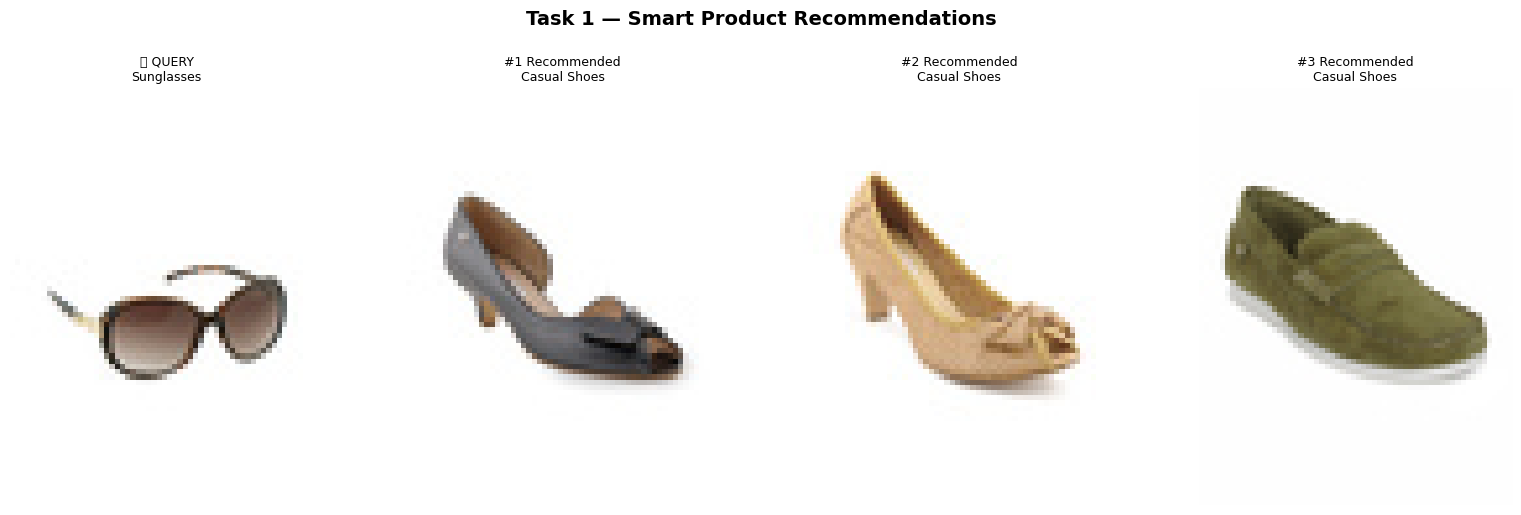

In [105]:
QUERY_IDX = 0   

query_product = df_indexed.iloc[QUERY_IDX]
print("🔍 QUERY PRODUCT")
print("=" * 50)
print(f"  Name     : {query_product['productDisplayName']}")
print(f"  Category : {query_product['masterCategory']} → {query_product['articleType']}")
print(f"  Colour   : {query_product['baseColour']}")
print(f"  Gender   : {query_product['gender']}")

result = recommend_complements(QUERY_IDX, top_k=3)
if result:
    rec_indices, rec_scores = result
    print(f"\n🛒 COMPLEMENTARY RECOMMENDATIONS")
    print("=" * 50)
    for rank, (idx, score) in enumerate(zip(rec_indices, rec_scores), 1):
        p = df_indexed.iloc[idx]
        print(f"  {rank}. {p['productDisplayName']}")
        print(f"     Type: {p['articleType']} | Colour: {p['baseColour']} | Score: {score:.3f}")

    all_indices = [QUERY_IDX] + rec_indices
    all_titles  = [f"🔍 QUERY\n{query_product['articleType']}"]
    all_titles += [f"#{i+1} Recommended\n{df_indexed.iloc[idx]['articleType']}" for i, idx in enumerate(rec_indices)]
    show_product_grid(all_indices, all_titles, main_title="Task 1 — Smart Product Recommendations")

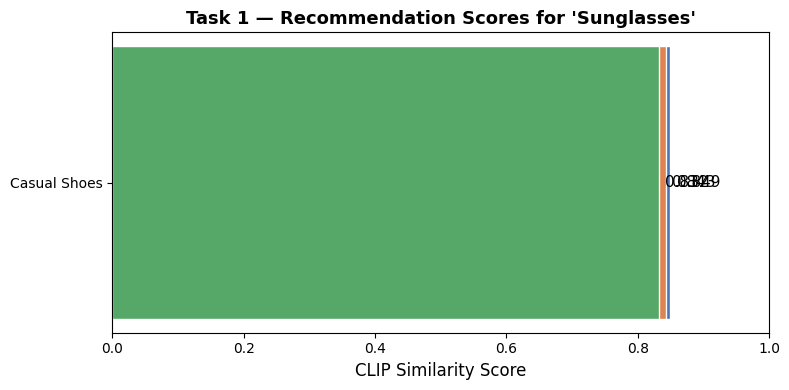

✅ Task 1 complete!


In [106]:
if result:
    rec_indices, rec_scores = result
    rec_names = [df_indexed.iloc[i]['articleType'] for i in rec_indices]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(rec_names, rec_scores, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
    ax.set_xlabel("CLIP Similarity Score", fontsize=12)
    ax.set_title(f"Task 1 — Recommendation Scores for '{query_product['articleType']}'", fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, score in zip(bars, rec_scores):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{score:.3f}", va='center', fontsize=11)
    plt.tight_layout()
    plt.savefig('task1_recommendation_scores.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Task 1 complete!")

---

# 🎯 Task 2 — Unique Product Catalog Creation (Deduplication)

**Problem:** Large marketplaces have duplicate/near-duplicate listings. Build a system to keep only unique products.  
**Approach:** CLIP embeddings + cosine similarity clustering → one representative per group.

In [108]:
SIMILARITY_THRESHOLD = 0.92   

def deduplicate_catalog(embs: np.ndarray, df_in: pd.DataFrame,
                        threshold: float = SIMILARITY_THRESHOLD):
    """
    Greedy dedup: iterate products in order.
    Each product is a 'representative' unless its cosine sim
    with an already-chosen representative exceeds `threshold`.
    Returns the unique indices and a group mapping.
    """
    n = len(embs)
    sim_matrix = cosine_similarity(embs)   # (N, N)
    
    chosen    = []       
    group_map = {}        
    grouped   = set()
    
    for i in range(n):
        if i in grouped:
            continue
        chosen.append(i)
        group_map[i] = i
        # Mark all similar products as duplicates of i
        for j in range(i + 1, n):
            if j not in grouped and sim_matrix[i, j] > threshold:
                grouped.add(j)
                group_map[j] = i
    
    return chosen, group_map, sim_matrix

print(f"⏳ Running deduplication (threshold = {SIMILARITY_THRESHOLD})...")
unique_indices, group_map, sim_matrix = deduplicate_catalog(embeddings, df_indexed)

df_unique = df_indexed.iloc[unique_indices].reset_index(drop=True)
duplicates_removed = len(df_indexed) - len(df_unique)

print(f"\n✅ Deduplication complete!")
print(f"   Original products  : {len(df_indexed):>5}")
print(f"   Unique products    : {len(df_unique):>5}")
print(f"   Duplicates removed : {duplicates_removed:>5}  ({duplicates_removed/len(df_indexed)*100:.1f}%)")

⏳ Running deduplication (threshold = 0.92)...

✅ Deduplication complete!
   Original products  :   500
   Unique products    :   328
   Duplicates removed :   172  (34.4%)


In [109]:
from collections import defaultdict

groups = defaultdict(list)
for idx, rep in group_map.items():
    groups[rep].append(idx)

duplicate_groups = {k: v for k, v in groups.items() if len(v) > 1}

print(f"🔍 Found {len(duplicate_groups)} duplicate groups")
print()

for group_num, (rep, members) in enumerate(list(duplicate_groups.items())[:3], 1):
    print(f"Group {group_num}: {len(members)} similar products")
    for m in members:
        p = df_indexed.iloc[m]
        tag = "[KEPT - representative]" if m == rep else "[DUPLICATE - removed]"
        print(f"  {tag}")
        print(f"    {p['productDisplayName']} | {p['articleType']} | {p['baseColour']}")
    print()

🔍 Found 70 duplicate groups

Group 1: 10 similar products
  [KEPT - representative]
    Image Women Classic Eyewear Brown Sunglasses | Sunglasses | Brown
  [DUPLICATE - removed]
    Opium Men Aviator Pink Sunglasses | Sunglasses | Steel
  [DUPLICATE - removed]
    Opium Men Aviator Black Sunglass | Sunglasses | Black
  [DUPLICATE - removed]
    Ray-Ban Men Shiny Hawana Black Sunglasses | Sunglasses | Black
  [DUPLICATE - removed]
    M tv Women My Fab Eyewear Brown Sunglasses | Sunglasses | Brown
  [DUPLICATE - removed]
    Louis Philippe Men Grey Sunglasses | Sunglasses | Grey
  [DUPLICATE - removed]
    Idee Women Funky Eyewear Brown Sunglasses | Sunglasses | Brown
  [DUPLICATE - removed]
    Van Heusen Unisex Sunglasses VH213-C3 | Sunglasses | Brown
  [DUPLICATE - removed]
    Polaroid Women Sunglasses | Sunglasses | Grey
  [DUPLICATE - removed]
    United Colors of Benetton Men Black Sunglasses | Sunglasses | Black

Group 2: 3 similar products
  [KEPT - representative]
    Titan Me

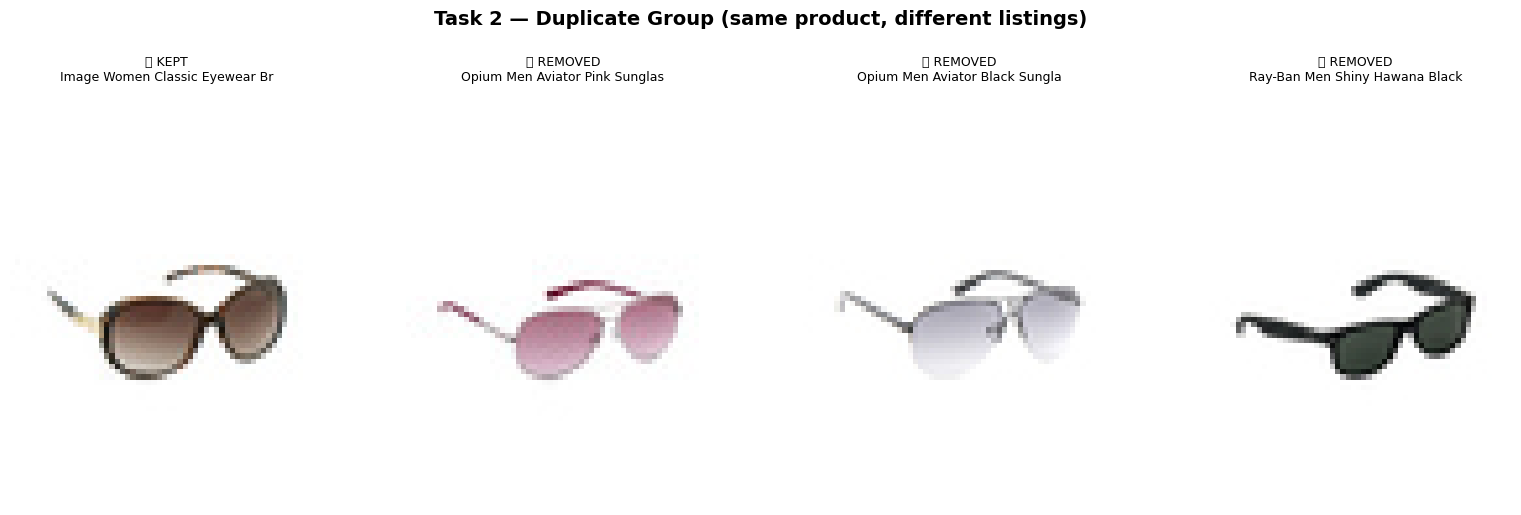

In [110]:
if duplicate_groups:
    rep_idx = list(duplicate_groups.keys())[0]
    group_members = duplicate_groups[rep_idx][:4] 

    titles = []
    for m in group_members:
        tag = "✅ KEPT" if m == rep_idx else "❌ REMOVED"
        titles.append(f"{tag}\n{df_indexed.iloc[m]['productDisplayName'][:30]}")

    show_product_grid(group_members, titles,
                      main_title="Task 2 — Duplicate Group (same product, different listings)")

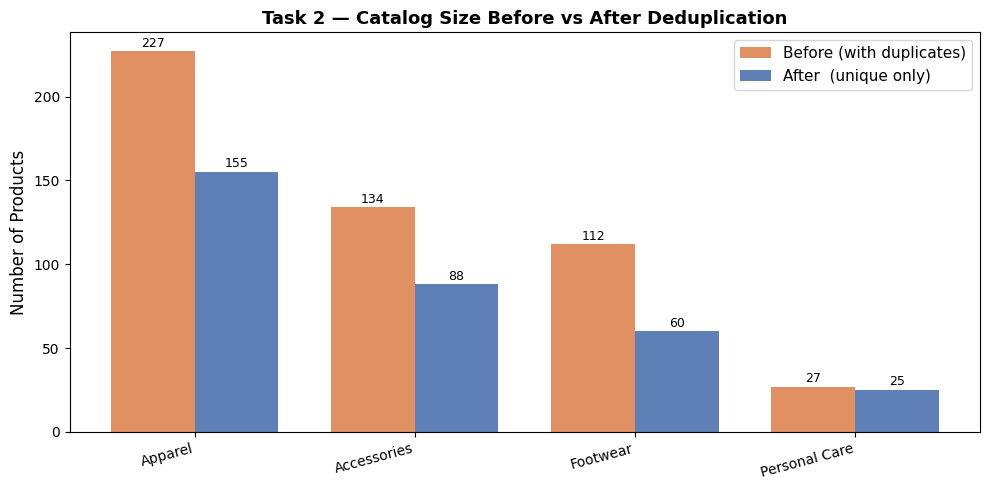

✅ Task 2 complete!


In [111]:
category_before = df_indexed['masterCategory'].value_counts().head(6)
category_after  = df_unique['masterCategory'].value_counts().reindex(category_before.index, fill_value=0)

x = np.arange(len(category_before))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, category_before.values, width, label='Before (with duplicates)', color='#DD8452', alpha=0.9)
bars2 = ax.bar(x + width/2, category_after.values,  width, label='After  (unique only)',     color='#4C72B0', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(category_before.index, rotation=15, ha='right')
ax.set_ylabel("Number of Products", fontsize=12)
ax.set_title("Task 2 — Catalog Size Before vs After Deduplication", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('task2_deduplication.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 2 complete!")

---

# 🎯 Task 3 — Reverse Product Search (Text → Products)

**Problem:** Allow users to search the catalogue using natural language instead of an image.  
**Approach:** CLIP encodes both images and text in the **same embedding space**, so we embed the query text and search the existing FAISS image index directly — no retraining needed!

In [114]:
def get_clip_text_embedding(text: str) -> np.ndarray:
    """Return normalised 512-D CLIP embedding for a text query."""
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)
    features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy().astype(np.float32)

def text_search(query: str, top_k: int = 5):
    """Search the FAISS index using a text query."""
    text_emb = get_clip_text_embedding(query)         # (1, 512)
    scores, indices = faiss_index.search(text_emb, top_k)
    return indices[0], scores[0]

print("✅ Text search function ready!")

✅ Text search function ready!


In [115]:
def get_clip_text_embedding(text: str):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model.text_model(**inputs)
        features = outputs.pooler_output
        features = clip_model.text_projection(features)
    features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy().astype(np.float32)

def text_search(query: str, top_k: int = 5):
    text_emb = get_clip_text_embedding(query)
    scores, indices = faiss_index.search(text_emb, top_k)
    return indices[0], scores[0]

QUERIES = [
    "blue casual shirt for men",
    "red dress for women",
    "white sports shoes",
    "black leather handbag",
]

for query in QUERIES:
    print(f"\n🔍 Query: \"{query}\"")
    print("-" * 55)
    idxs, scores = text_search(query, top_k=5)
    for rank, (idx, score) in enumerate(zip(idxs, scores), 1):
        p = df_indexed.iloc[idx]
        print(f"  {rank}. [{score:.3f}] {p['productDisplayName']}")
        print(f"         {p['articleType']} | {p['baseColour']} | {p['gender']}")


🔍 Query: "blue casual shirt for men"
-------------------------------------------------------
  1. [0.332] French Connection Men Light Blue Shirt
         Shirts | Blue | Men
  2. [0.325] Wrangler Men Stampede Green Shirt
         Shirts | Green | Men
  3. [0.323] Basics Men Navy Shirt
         Shirts | Navy Blue | Men
  4. [0.321] Highlander Men Check Blue Shirt
         Shirts | Blue | Men
  5. [0.321] Myntra Men Blue and Green  Check Shirt
         Shirts | Blue | Men

🔍 Query: "red dress for women"
-------------------------------------------------------
  1. [0.313] United Colors of Benetton Women Light Winter Red Tops
         Tops | Red | Women
  2. [0.310] BIBA Women Solid Red Kurta
         Kurtas | Red | Women
  3. [0.308] Aurelia Women Maroon Kurta
         Kurtas | Maroon | Women
  4. [0.304] Gini and Jony Girl's Glinda Red Kidswear
         Skirts | Red | Women
  5. [0.302] Arrow Woman Red Top
         Tops | Red | Women

🔍 Query: "white sports shoes"
----------------------

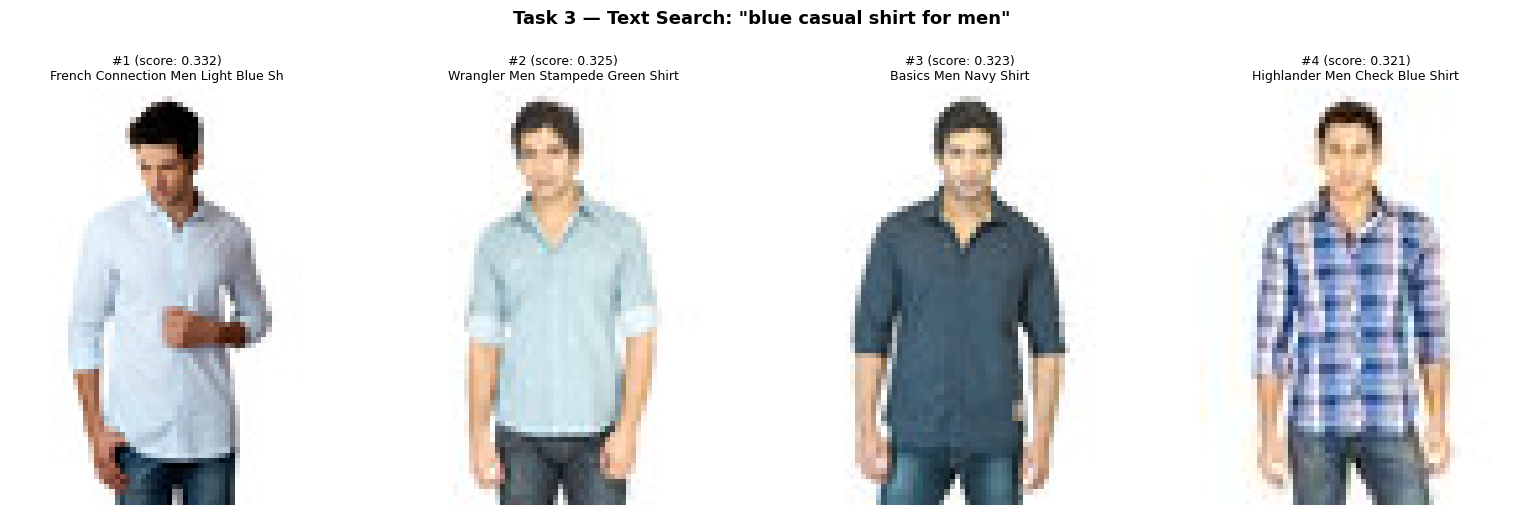

In [116]:
DEMO_QUERY = "blue casual shirt for men"

idxs, scores = text_search(DEMO_QUERY, top_k=4)

titles = [f"#{i+1} (score: {score:.3f})\n{df_indexed.iloc[idx]['productDisplayName'][:35]}"
          for i, (idx, score) in enumerate(zip(idxs, scores))]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(f'Task 3 — Text Search: "{DEMO_QUERY}"', fontsize=13, fontweight='bold', y=1.02)
for ax, idx, title in zip(axes, idxs, titles):
    img = Image.open(df_indexed.iloc[idx]['image_path']).convert("RGB")
    ax.imshow(img)
    ax.set_title(title, fontsize=9, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.savefig('task3_text_search.png', dpi=150, bbox_inches='tight')
plt.show()

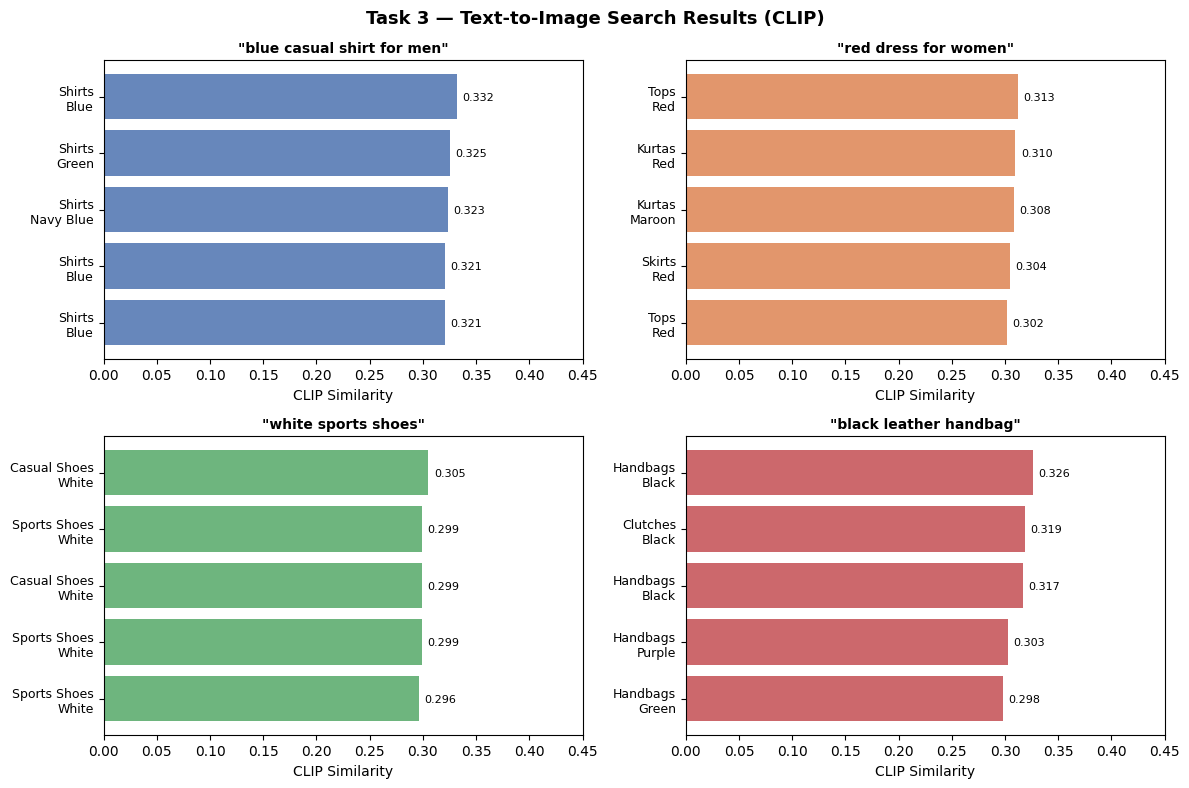

✅ Task 3 complete!


In [117]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, query, color in zip(axes, QUERIES, colors):
    idxs, scores = text_search(query, top_k=5)
    labels = [df_indexed.iloc[i]['articleType'] + "\n" +
              df_indexed.iloc[i]['baseColour'][:10] for i in idxs]
    bars = ax.barh(range(len(scores)), scores, color=color, alpha=0.85)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("CLIP Similarity", fontsize=10)
    ax.set_title(f'"{query}"', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 0.45)
    ax.invert_yaxis()
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{score:.3f}", va='center', fontsize=8)

plt.suptitle("Task 3 — Text-to-Image Search Results (CLIP)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_multi_query_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 3 complete!")

---

# 📊 Final Summary Dashboard

In [119]:
print("=" * 60)
print("          AI PRODUCT INTELLIGENCE SYSTEM — SUMMARY")
print("=" * 60)
print()
print("📦 DATASET")
print(f"   Total products    : {len(df):,}")
print(f"   Sample used       : {len(df_indexed)}")
print(f"   Embedding dim     : 512 (CLIP ViT-B/32)")
print(f"   Index type        : FAISS IndexFlatIP (cosine)")
print()
print("🎯 TASK 1 — Smart Recommendation Engine")
print(f"   Method            : Category map + CLIP similarity")
print(f"   Complement types  : {len(COMPLEMENT_MAP)} categories mapped")
print(f"   Top-K returned    : 3 per query")
print()
print("🎯 TASK 2 — Unique Catalog Creation")
print(f"   Method            : Greedy cosine clustering")
print(f"   Threshold          : {SIMILARITY_THRESHOLD}")
print(f"   Before            : {len(df_indexed)} products")
print(f"   After (unique)    : {len(df_unique)} products")
print(f"   Duplicates found  : {duplicates_removed} ({duplicates_removed/len(df_indexed)*100:.1f}%)")
print()
print("🎯 TASK 3 — Reverse Text Search")
print(f"   Method            : CLIP text embedding → FAISS search")
print(f"   Key insight       : Text & image share same latent space")
print(f"   Queries tested    : {len(QUERIES)}")
print()
print("=" * 60)
print("✅ All 3 tasks complete!  Ready for submission.")
print("=" * 60)

          AI PRODUCT INTELLIGENCE SYSTEM — SUMMARY

📦 DATASET
   Total products    : 44,419
   Sample used       : 500
   Embedding dim     : 512 (CLIP ViT-B/32)
   Index type        : FAISS IndexFlatIP (cosine)

🎯 TASK 1 — Smart Recommendation Engine
   Method            : Category map + CLIP similarity
   Complement types  : 16 categories mapped
   Top-K returned    : 3 per query

🎯 TASK 2 — Unique Catalog Creation
   Method            : Greedy cosine clustering
   Threshold          : 0.92
   Before            : 500 products
   After (unique)    : 328 products
   Duplicates found  : 172 (34.4%)

🎯 TASK 3 — Reverse Text Search
   Method            : CLIP text embedding → FAISS search
   Key insight       : Text & image share same latent space
   Queries tested    : 4

✅ All 3 tasks complete!  Ready for submission.


In [ ]:
def get_clip_text_embedding(text: str):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model.text_model(**inputs)
        features = outputs.pooler_output
        features = clip_model.text_projection(features)
    features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy().astype(np.float32)

def text_search(query: str, top_k: int = 5):
    text_emb = get_clip_text_embedding(query)
    scores, indices = faiss_index.search(text_emb, top_k)
    return indices[0], scores[0]

test = get_clip_text_embedding("blue shirt")
print(f"✅ Text embedding works! Shape: {test.shape}")

QUERIES = [
    "blue casual shirt for men",
    "red dress for women", 
    "white sports shoes",
    "black leather handbag",
]

for query in QUERIES:
    print(f"\n🔍 Query: '{query}'")
    print("-" * 50)
    idxs, scores = text_search(query, top_k=5)
    for rank, (idx, score) in enumerate(zip(idxs, scores), 1):
        p = df_indexed.iloc[idx]
        print(f"  {rank}. [{score:.3f}] {p['productDisplayName']}")
        print(f"         {p['articleType']} | {p['baseColour']} | {p['gender']}")